# Federated Learning — Algorithm Comparison (500 Rounds)

Compares **Centralized (baseline), FedAvg, FedProx, SCAFFOLD, FedDC**.

| Cell | Dataset | Partition |
|------|---------|----------|
| Experiment 1 | CASAS | Non-IID |
| Experiment 2 | CASAS | IID |
| Experiment 3 | UCI   | IID |
| Experiment 4 | UCI   | Non-IID |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

os.chdir("/home/clara/Research2.0/fyp_fl_smart_home")
print("CWD =", os.getcwd())

# ── Aesthetics ─────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.2,
    'grid.linestyle'    : '--',
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 12,
    'xtick.labelsize'   : 9.5,
    'ytick.labelsize'   : 9.5,
    'legend.fontsize'   : 9.5,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#cccccc',
    'figure.dpi'        : 140,
})

# ════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════
RESULTS_DIR = "results"
PLOTS_DIR   = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

ALGOS  = ["fedavg", "fedprox", "scaffold", "feddc"]
MODEL  = "cnn" # "lstm" | "cnn"
ROUNDS = 500
SMOOTH = 12       # rolling-avg window (1 = off)

# ── Algorithm styles ──────────────────────────────────────────
# centralized = black solid thick line (upper bound reference)
# FL algos    = distinct color + linestyle
ALGO_STYLES = {
    # key            color       ls                    lw    label
    "centralized": {"color": "#2d3a8c", "ls": "-",             "lw": 2.5},
    "fedavg":      {"color": "#e53e3e", "ls": "--",            "lw": 1.9},
    "fedprox":     {"color": "#d97706", "ls": "-.",            "lw": 1.9},
    "scaffold":    {"color": "#38a169", "ls": ":",             "lw": 2.0},
    "feddc":       {"color": "#805ad5", "ls": (0,(3,1,1,1)),  "lw": 2.0},
}

ALGO_LABELS = {
    "centralized": "Centralized (baseline)",
    "fedavg":      "FedAvg",
    "fedprox":     "FedProx",
    "scaffold":    "SCAFFOLD",
    "feddc":       "FedDC",
}

# ── Helpers ────────────────────────────────────────────────────
def load_dfs(dataset, partition):
    """Load FL algos + centralized baseline."""
    result = {}

    # ── 1. Centralized baseline ─────────────────────────────────
    central_path = os.path.join(RESULTS_DIR, f"{dataset}_{MODEL}_centralized_benchmark.csv")
    if os.path.exists(central_path):
        df = pd.read_csv(central_path)
        df["round"] = df["round"].astype(int)
        for col in ["loss", "accuracy", "f1"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        result["centralized"] = df
        print(f"  [OK] {os.path.basename(central_path)}  rounds={df['round'].max()}")
    else:
        print(f"  [WARN] centralized benchmark not found: {central_path}")

    # ── 2. FL algorithms ────────────────────────────────────────
    for algo in ALGOS:
        # try both naming conventions
        candidates = [
            f"{dataset}_{MODEL}_{algo}_{partition}_r{ROUNDS}_fl.csv",
            f"{dataset}_{MODEL}_{algo}_{partition}_a0.1_r{ROUNDS}_nodp.csv",
            f"{dataset}_{MODEL}_{algo}_{partition}_r{ROUNDS}_nodp.csv",
        ]
        found = None
        for fname in candidates:
            p = os.path.join(RESULTS_DIR, fname)
            if os.path.exists(p):
                found = p
                break
        if found is None:
            print(f"  [WARN] {algo} ({partition}) — not found, skipped.")
            continue
        df = pd.read_csv(found)
        df["round"] = df["round"].astype(int)
        for col in ["loss", "accuracy", "f1"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        result[algo] = df
        print(f"  [OK] {os.path.basename(found)}  rounds={df['round'].max()}")

    return result


def smooth(series, w):
    return series if w <= 1 else series.rolling(w, min_periods=1, center=True).mean()


def plot_experiment(dataset, partition, dfs):
    if not dfs:
        print("[!] No data to plot.")
        return

    metrics = [
        ("accuracy", "Accuracy", True,  "lower right"),
        ("f1",       "Macro F1", True,  "lower right"),
        ("loss",     "Loss",     False, "upper right"),
    ]

    # Draw order: centralized first (background ref), then FL algos on top
    draw_order = ["centralized"] + [a for a in ALGOS if a in dfs]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for ax, (col, ylabel, is_pct, leg_loc) in zip(axes, metrics):
        for algo in draw_order:
            if algo not in dfs:
                continue
            df = dfs[algo]
            if col not in df.columns:
                continue
            st    = ALGO_STYLES.get(algo, {"color": "#888", "ls": "-", "lw": 1.5})
            label = ALGO_LABELS.get(algo, algo.upper())

            # Centralized: draw as horizontal-ish reference with slight alpha
            alpha = 0.65 if algo == "centralized" else 0.95

            ax.plot(
                df["round"],
                smooth(df[col], SMOOTH),
                color=st["color"], ls=st["ls"], lw=st["lw"],
                label=label, alpha=alpha,
                solid_capstyle="round",
                zorder=2 if algo == "centralized" else 3,
            )

        ax.set_xlabel("Communication Round", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        if is_pct:
            ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_title(f"{ylabel} vs Rounds", fontsize=11, fontweight="bold", pad=8)
        ax.legend(
            loc=leg_loc,
            title="Algorithm",
            title_fontsize=8.5,
            fontsize=8.5,
        )

    part_label = "Non-IID" if partition == "non_iid" else "IID"
    fig.suptitle(
        f"{dataset.upper()} · {MODEL.upper()} · {part_label} — Algorithm Comparison ({ROUNDS} rounds)",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()

    fname = f"{dataset}_{MODEL}_{partition}_compare.png"
    out   = os.path.join(PLOTS_DIR, fname)
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out}")
    plt.show()


print("Config and helpers loaded.")

CWD = /home/clara/Research2.0/fyp_fl_smart_home
Config and helpers loaded.


## Experiment 1 — CASAS · Non-IID

Loading CASAS Non-IID...
  [OK] casas_cnn_centralized_benchmark.csv  rounds=500
  [OK] casas_cnn_fedavg_non_iid_r500_fl.csv  rounds=500
  [OK] casas_cnn_fedprox_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] casas_cnn_scaffold_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] casas_cnn_feddc_non_iid_r500_fl.csv  rounds=500
Saved -> results/plots/casas_cnn_non_iid_compare.png


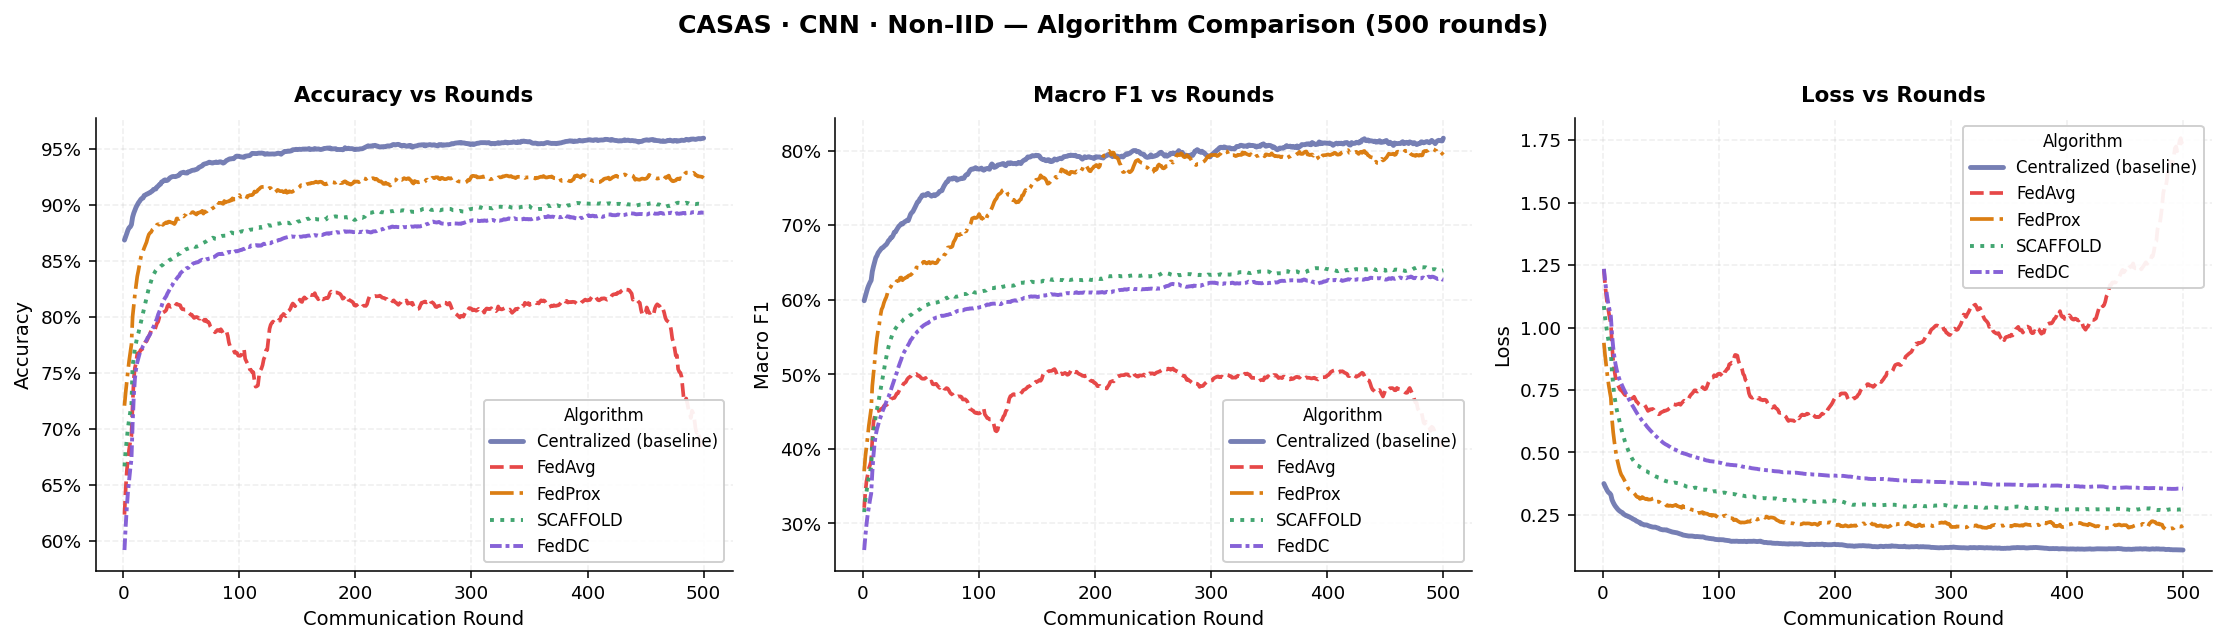

In [2]:
print("Loading CASAS Non-IID...")
dfs = load_dfs("casas", "non_iid")
plot_experiment("casas", "non_iid", dfs)

## Experiment 2 — CASAS · IID

Loading CASAS IID...
  [OK] casas_cnn_centralized_benchmark.csv  rounds=500
  [OK] casas_cnn_fedavg_iid_r500_fl.csv  rounds=500
  [OK] casas_cnn_fedprox_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] casas_cnn_scaffold_iid_r500_fl.csv  rounds=500
  [OK] casas_cnn_feddc_iid_r500_fl.csv  rounds=500
Saved -> results/plots/casas_cnn_iid_compare.png


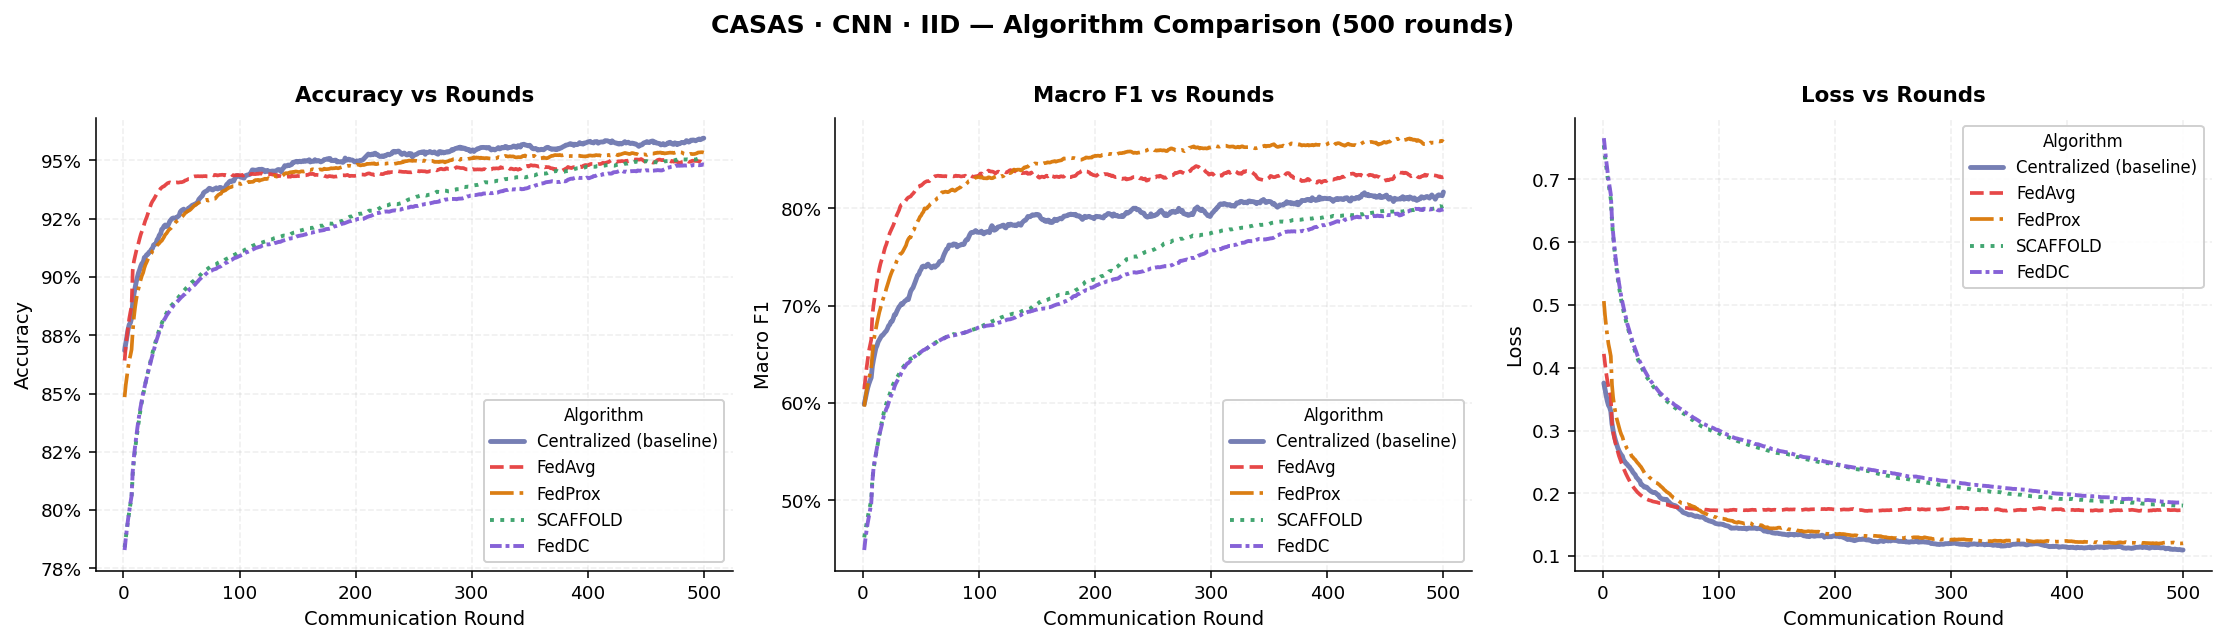

In [3]:
print("Loading CASAS IID...")
dfs = load_dfs("casas", "iid")
plot_experiment("casas", "iid", dfs)

## Experiment 3 — UCI · IID

Loading UCI IID...
  [OK] uci_cnn_centralized_benchmark.csv  rounds=500
  [OK] uci_cnn_fedavg_iid_r500_fl.csv  rounds=500
  [OK] uci_cnn_fedprox_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] uci_cnn_scaffold_iid_r500_fl.csv  rounds=500
  [OK] uci_cnn_feddc_iid_r500_fl.csv  rounds=500
Saved -> results/plots/uci_cnn_iid_compare.png


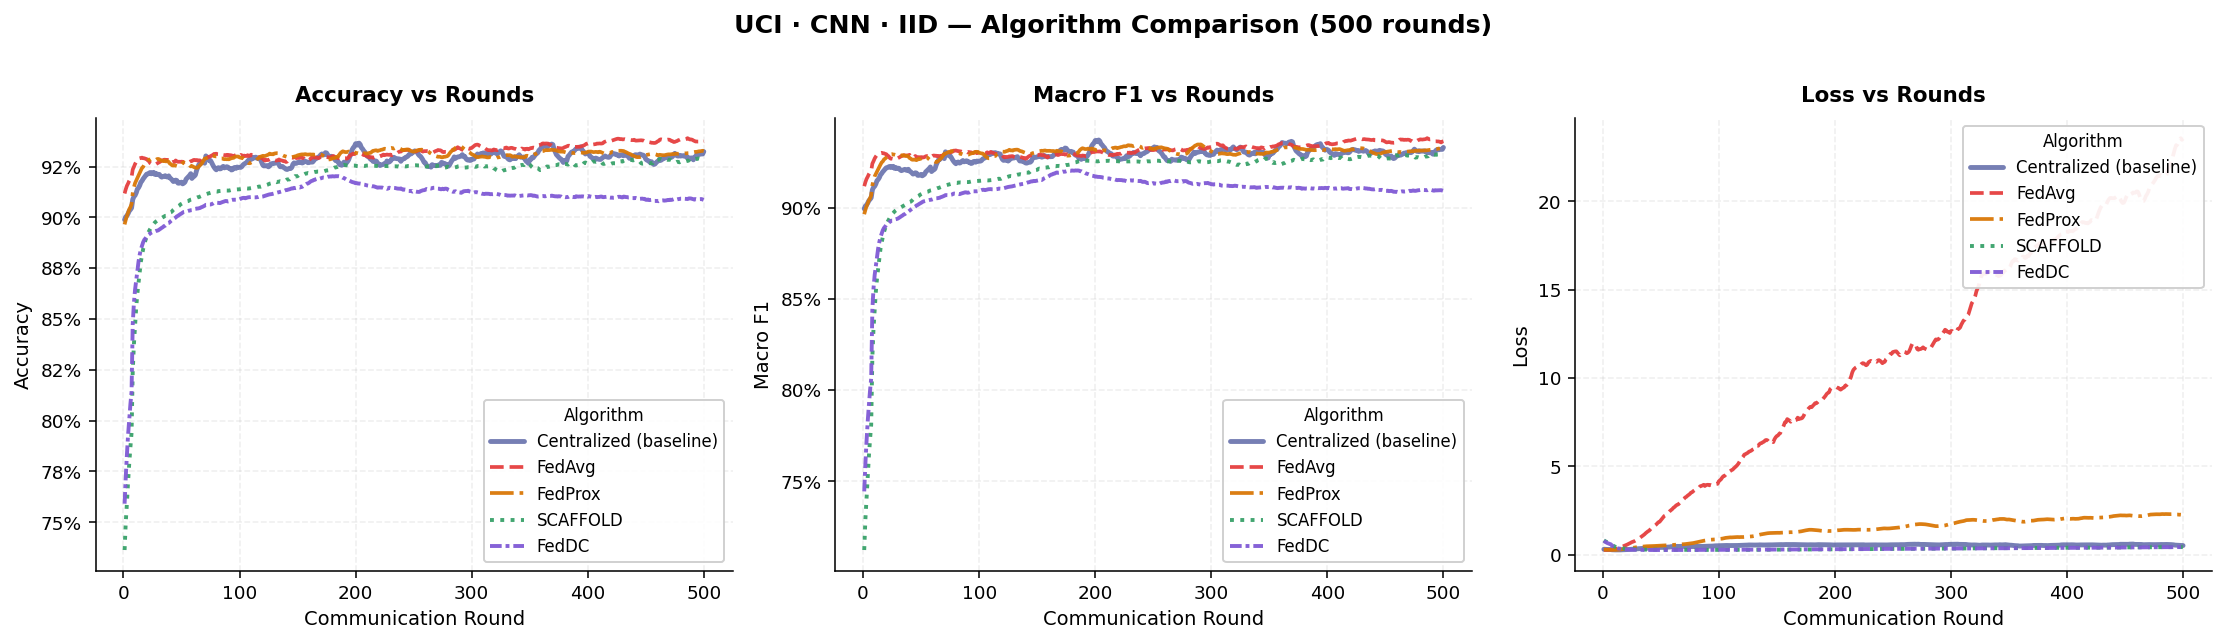

In [4]:
print("Loading UCI IID...")
dfs = load_dfs("uci", "iid")
plot_experiment("uci", "iid", dfs)

## Experiment 4 — UCI · Non-IID

Loading UCI Non-IID...
  [OK] uci_cnn_centralized_benchmark.csv  rounds=500
  [OK] uci_cnn_fedavg_non_iid_r500_fl.csv  rounds=500
  [OK] uci_cnn_fedprox_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] uci_cnn_scaffold_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] uci_cnn_feddc_non_iid_r500_fl.csv  rounds=500
Saved -> results/plots/uci_cnn_non_iid_compare.png


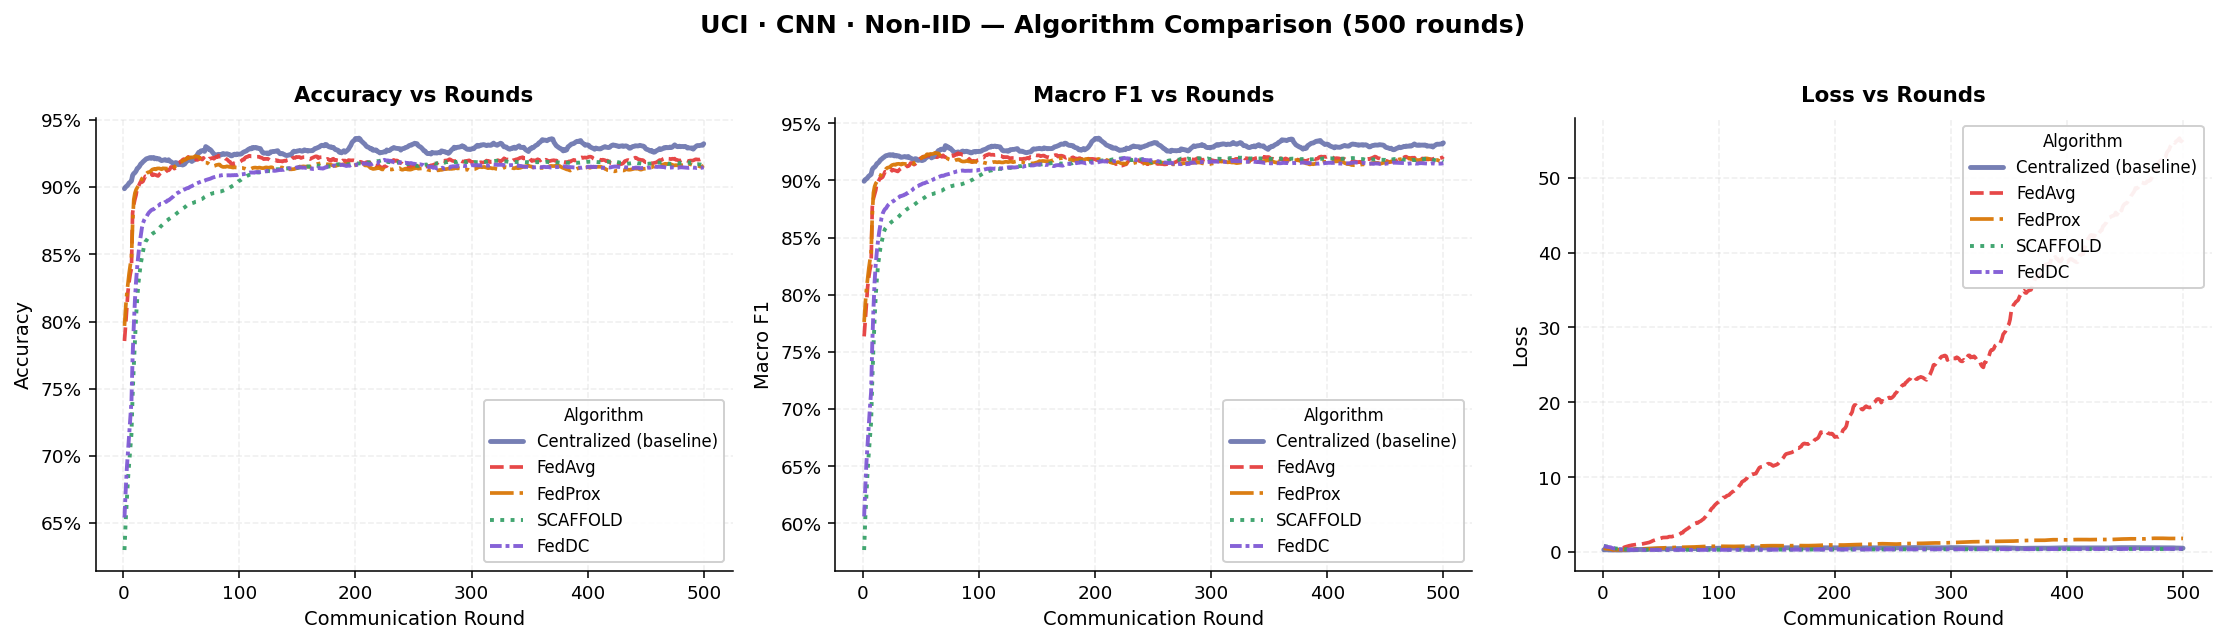

In [5]:
print("Loading UCI Non-IID...")
dfs = load_dfs("uci", "non_iid")
plot_experiment("uci", "non_iid", dfs)